# Wavenet

In [1]:
import numpy as np
import pywt
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from sktime.datasets import load_from_tsfile_to_dataframe
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch.nn.functional as F
import torch.nn as nn
from torch.optim.lr_scheduler import StepLR
import pandas as pd
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import json
import os

In [2]:
import torch
import torch.nn as nn

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, 
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, 
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # Shortcut connection
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, 
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(identity) # The ResNet connection
        out = self.relu(out)
        return out

def CNN_model(mode='CWT'):
    """
    Deeper ResNet-based architecture for 20x20 input.
    """
    # Initial Conv layer
    layers = [
        nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1, bias=False),
        nn.BatchNorm2d(16),
        nn.ReLU(inplace=True)
    ]
    
    # Residual Blocks
    layers.append(ResidualBlock(16, 16))   # Block 1 (20x20)
    layers.append(ResidualBlock(16, 32, stride=2)) # Block 2 (10x10) - Downsample
    layers.append(ResidualBlock(32, 32))   # Block 3 (10x10)
    layers.append(ResidualBlock(32, 64, stride=2)) # Block 4 (5x5) - Downsample
    
    # Classifier Head
    layers.extend([
        nn.Flatten(),
        nn.Linear(64 * 5 * 5, 128),
        nn.BatchNorm1d(128),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4)
    ])

    if mode.upper() == 'CIFAR':
        layers.append(nn.Linear(128, 10))
    else:
        layers.append(nn.Linear(128, 1))
        layers.append(nn.Sigmoid())

    return nn.Sequential(*layers)

In [3]:
def model_fit(train_loader, device, mode='CWT', weights=None):
    """
    mode: 'CWT' (Binary) or 'CIFAR' (10-class)
    weights: state_dict containing pre-trained base layers
    """
    model = CNN_model(mode=mode).to(device)
    
    # 1. Load weights if provided
    if weights is not None:
        # Create a filtered dictionary to avoid shape mismatch on the final layers
        # In your Sequential model, layers 15 (Linear), 16 (BN), 18 (Linear) are the head components
        # We want to keep the base (convs/flatten) and potentially the first Linear (15) 
        # but DEFINITELY remove the final classifier layer (18)
        
        filtered_weights = {k: v for k, v in weights.items() if not k.startswith('18.')}
        
        # Load only the matching base layers
        model.load_state_dict(filtered_weights, strict=False)
        print(f"Base weights loaded for {mode} mode. Layer 18 (Classification Head) reset.")
    else:
        print(f"No weights provided. Training {mode} model from scratch.")

    # 2. Select Criterion based on mode
    if mode.upper() == 'CIFAR':
        criterion = nn.CrossEntropyLoss()
    else:
        criterion = nn.BCELoss()

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = StepLR(optimizer, step_size=8, gamma=0.3)
    
    epochs = 150 
    
    for epoch in tqdm(range(epochs), desc=f"Training {mode}:", total=epochs):
        model.train()
        total_loss = 0
    
        for x, y in train_loader:
            x = x.to(device)
            
            # 3. Handle target format differences
            if mode.upper() == 'CIFAR':
                y = y.to(device).long() 
            else:
                y = y.to(device).float().unsqueeze(1) 
    
            outputs = model(x)
            loss = criterion(outputs, y)
    
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    
            total_loss += loss.item()
    
        scheduler.step()

    return model, model.state_dict()

In [11]:
class CIFAR10Dataset(Dataset):
    def __init__(self, train=True, img_size=(20, 20)):
        """
        Args:
            train (bool): Load training or test set.
            img_size (tuple): Target size to match your CWT scale/time dimensions.
        """
        self.samples = []
        self.labels = []
        
        # 1. Define transforms: Convert to Tensor, Grayscale (1-channel), and Resize
        transform_pipeline = transforms.Compose([
            transforms.Grayscale(num_output_channels=1),
            transforms.Resize(img_size),
            transforms.ToTensor(),
            # Normalizing helps the CNN learn faster
            transforms.Normalize((0.5,), (0.5,)) 
        ])

        # 2. Download/Load CIFAR10
        cifar_data = datasets.CIFAR10(
            root='./data', 
            train=train, 
            download=True, 
            transform=transform_pipeline
        )

        # 3. Process into list to match your CWT class structure
        # Note: We loop once to match your self.samples list-based structure
        for img, label in tqdm(cifar_data, desc=f"Loading CIFAR10 {'Train' if train else 'Test'}"):
            self.samples.append(img)
            self.labels.append(label)

    def plot(self, idx):
        # Matches your plotting logic
        img = self.samples[idx].squeeze(0).numpy()
        plt.imshow(img, cmap='gray', aspect='auto')
        plt.title(f"CIFAR10 Grayscale - Label: {self.labels[idx]}")
        plt.colorbar()
        plt.show()

    def resize_images(self, new_size=(20, 20)):
        # Re-using your interpolation logic for consistency
        resized_samples = []
        for img in tqdm(self.samples, desc="Resizing CIFAR images"):
            resized_img = torch.nn.functional.interpolate(
                img.unsqueeze(0), size=new_size, mode='bilinear', align_corners=False
            )
            resized_samples.append(resized_img.squeeze(0))
        self.samples = resized_samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx], self.labels[idx]

In [4]:
def evaluate_metrics(model, dataloader, device, mode='CWT', threshold=0.5):
    model.eval()

    y_true_all = []
    y_pred_all = []
    y_proba_all = []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            # 1. Handle targets based on mode
            if mode.upper() == 'CIFAR':
                y_true = y.to(device).long()
            else:
                y_true = y.to(device).float().view(-1)
            
            outputs = model(x)

            # 2. Extract Predictions and Probabilities
            if mode.upper() == 'CIFAR':
                # For CIFAR, we take the index of the highest logit
                probs = torch.softmax(outputs, dim=1) 
                preds = torch.argmax(outputs, dim=1)
                y_proba_all.append(probs.cpu()) # Store full distribution for AUC
            else:
                # For CWT (Binary)
                probs = outputs.view(-1).float()
                preds = (probs >= threshold).float()
                y_proba_all.append(probs.cpu())

            y_true_all.append(y_true.cpu())
            y_pred_all.append(preds.cpu())

    y_test = torch.cat(y_true_all).numpy()
    y_pred = torch.cat(y_pred_all).numpy()
    y_proba = torch.cat(y_proba_all).numpy()

    # 3. Calculate Metrics
    if mode.upper() == 'CIFAR':
        # Use 'macro' averaging for multi-class
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        try:
            # Multi-class AUC requires 'ovr' (One-vs-Rest)
            auc = roc_auc_score(y_test, y_proba, multi_class='ovr')
        except ValueError:
            auc = float("nan")
    else:
        # Standard Binary logic
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        try:
            auc = roc_auc_score(y_test, y_proba)
        except ValueError:
            auc = float("nan")

    return accuracy, recall, precision, f1, auc

In [13]:
def train_base_model():
    # 1. Setup device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f'Using device: {device}')

    # 2. Initialize your new CIFAR10Dataset (Grayscale + Resized to 20x20)
    # We use 20x20 to stay consistent with your 32*5*5 hardcoded linear layer
    train_dataset = CIFAR10Dataset(train=True, img_size=(20, 20))
    val_dataset = CIFAR10Dataset(train=False, img_size=(20, 20))
    
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

    # 3. Train the model in 'CIFAR' mode
    # This automatically sets output to 10 nodes and uses CrossEntropyLoss
    model, base_weights = model_fit(train_loader, device, mode='CIFAR')

    # 4. Evaluate using multi-class logic
    accuracy, recall, precision, f1, auc = evaluate_metrics(
        model, 
        val_loader, 
        device, 
        mode='CIFAR'
    )
    
    result_dict = {
        "data_name" : "CIFAR-10",
        "model" : "WaveNet_Base",
        "Accuracy" : accuracy,
        "Precision" : precision,
        "Recall" : recall,
        "F1-score" : f1,
        "ROC-AUC score" : auc
    }

    # base_weights contains the 'knowledge' to be transferred to the Churn task
    return model, base_weights, result_dict

In [14]:
model, base_weights, metrics = train_base_model()


Using device: cuda


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 170498071/170498071 [00:18<00:00, 9372791.55it/s]


Extracting ./data/cifar-10-python.tar.gz to ./data


Loading CIFAR10 Train: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50000/50000 [00:03<00:00, 15496.18it/s]


Files already downloaded and verified


Loading CIFAR10 Test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:00<00:00, 15403.53it/s]


No weights provided. Training CIFAR model from scratch.


Training CIFAR:: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [03:39<00:00,  1.47s/it]


In [15]:
torch.save(base_weights, 'base_weights-cifar.pth')


In [17]:
print(metrics)

{'data_name': 'CIFAR-10', 'model': 'WaveNet_Base', 'Accuracy': 0.7028, 'Precision': 0.7084685737324907, 'Recall': 0.7028000000000001, 'F1-score': 0.6995706322050805, 'ROC-AUC score': 0.9557201388888888}


In [11]:
def cwt_transform(signal, wavelet='morl', scales=np.arange(1, 21)):
    signal = np.array(signal)
    coefs, _ = pywt.cwt(signal, scales, wavelet)
    return coefs  # shape: [scale, time]

In [12]:
class CWTTimeSeriesDataset(Dataset):
    def __init__(self, x_df, y_list, wavelet, scales):
        self.samples = []
        self.labels = []

        for i in tqdm(range(len(x_df)), desc="Processing CWT"):
            ts = x_df.iloc[i].iloc[0]
            img = cwt_transform(ts, wavelet, scales)
            img = np.expand_dims(img, axis=0)  # shape: [1, scale, time]
            self.samples.append(torch.tensor(img, dtype=torch.float32))
            self.labels.append(int(y_list[i]))

    def plot(self, idx):
        img = self.samples[idx].squeeze(0).numpy()  # shape: [scale, time]
        plt.imshow(
            img,
            extent=[0, img.shape[1], 1, img.shape[0] + 1],
            cmap='PRGn',
            aspect='auto',
            vmax=abs(img).max(),
            vmin=-abs(img).max()
        )
        plt.title(f"CWT of Sample {idx}")
        plt.ylabel('Scale')
        plt.xlabel('Time')
        plt.colorbar(label='Amplitude')
        plt.show()

    def resize_images(self, new_size=(224, 224)):
        resized_samples = []
        for img in tqdm(self.samples, desc="Resizing images"):
            resized_img = F.interpolate(img.unsqueeze(0), size=new_size, mode='bilinear', align_corners=False)
            resized_samples.append(resized_img.squeeze(0))
        self.samples = resized_samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx], self.labels[idx]


In [20]:
wavelet='morl'
scales=np.arange(1, 21)

train_dataset = CWTTimeSeriesDataset(x_train, y_train, wavelet, scales)
val_dataset = CWTTimeSeriesDataset(x_test, y_test, wavelet, scales)

# # Resize
# train_dataset.resize_images(new_size=(224, 224))
# val_dataset.resize_images(new_size=(224, 224))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

NameError: name 'x_train' is not defined

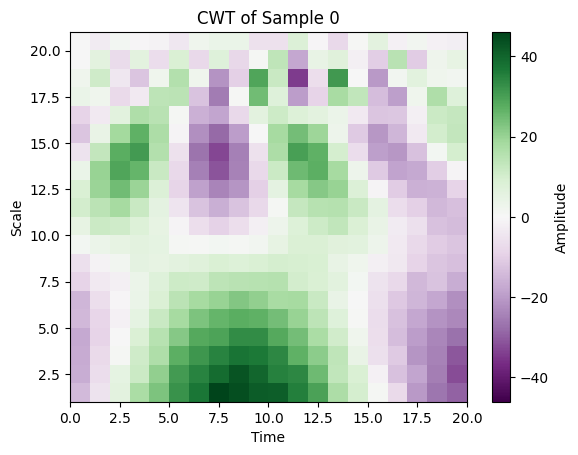

In [18]:
train_dataset.plot(idx=0)

In [13]:
def wl_train_and_test(data_name, base_weights):

    wavelet = 'morl'
    scales = np.arange(1, 21)
    
    data_id = data_name[4:6]
    file_path_train = f"data/{data_name}/TokenItaly_vers0/TokenItaly_vers0_TRAIN.ts"
    file_path_test = f"data/{data_name}/TokenItaly_vers0/TokenItaly_vers0_TEST.ts"

    x_train, y_train = load_from_tsfile_to_dataframe(file_path_train)
    x_test, y_test = load_from_tsfile_to_dataframe(file_path_test)

    # Note: Ensure these generate 20x20 images to match the CIFAR pre-training dims
    train_dataset = CWTTimeSeriesDataset(x_train, y_train, wavelet, scales)
    val_dataset = CWTTimeSeriesDataset(x_test, y_test, wavelet, scales)
    
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f'Using device: {device} for data: {data_name}')

    # --- Transfer Learning Step ---
    # We specify mode='CWT' and pass the base_weights. 
    # model_fit handles the surgery (keeping convs, resetting the linear head).
    model, _ = model_fit(train_loader, device, mode='CWT', weights=base_weights)
    
    # Evaluate using binary mode (standard for your churn task)
    accuracy, recall, precision, f1, auc = evaluate_metrics(model, val_loader, device, mode='CWT')
    
    result_dict = {
        "data_id" : data_id,
        "data_name" : data_name,
        "model" : "WaveNet_TL_Resnet_Base",
        "Accuracy" : accuracy,
        "Precision" : precision,
        "Recall" : recall,
        "F1-score" : f1,
        "ROC-AUC score" : auc
    }

    return result_dict

In [14]:
json_path = 'results.json'
csv_path = 'results.csv'

if os.path.exists(json_path):
    with open(json_path, 'r') as f:
        all_results = json.load(f)
else:
    all_results = []

data_root_path = 'data'
data_names = sorted([
    name for name in os.listdir(data_root_path)
    if os.path.isdir(os.path.join(data_root_path, name)) and name.startswith('data')
])

c = 0
for data_name in data_names:
    result_dict = wl_train_and_test(data_name, None)
    all_results.append(result_dict)
    c += 1
    print(data_name)

with open(json_path, 'w') as f:
    json.dump(all_results, f, indent=2)


df = pd.DataFrame(all_results)
df.to_csv(csv_path, index=False)

print(f"{c} data is trained and results added to the files...")

Processing CWT: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4970/4970 [00:01<00:00, 3080.38it/s]


Using device: cuda for data: data10_IC1_FM_label_wl_20_pw_0_unwo_dropped_1_1_ratio_full_data
No weights provided. Training CWT model from scratch.


Training CWT:: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [02:34<00:00,  1.03s/it]


data10_IC1_FM_label_wl_20_pw_0_unwo_dropped_1_1_ratio_full_data


Processing CWT: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12425/12425 [00:04<00:00, 3071.08it/s]


...

data40_LGSR_FM_label_wl_20_pw_0_unwo_dropped_1_1_ratio_full_data


Processing CWT: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1500/1500 [00:00<00:00, 3150.38it/s]


Using device: cuda for data: data41_LGSR_FM_label_wl_20_pw_0_unwo_dropped_1_4_ratio_full_data
No weights provided. Training CWT model from scratch.


Training CWT:: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [00:47<00:00,  3.18it/s]

data41_LGSR_FM_label_wl_20_pw_0_unwo_dropped_1_4_ratio_full_data
12 data is trained and results added to the files...
